## Aritficial Neural Net with Vairabe Architecture and Back Propagation

In [2]:
import numpy as np
import pandas as pandas
import matplotlib.pyplot as plt

In [3]:
from matplotlib.colors import ListedColormap
cmap_bold = ListedColormap(["#FF0000","#00FF00","#0000FF"])
cmap_light = ListedColormap(["#FFBBBB","#BBFFBB","#BBBBFF"])

### Utils

In [11]:
#Activatoins
def linear(H):
    return H

def sigmoid(H):
    return 1/(1+np.exp(-H))

def ReLU(H):
    return H*(H>0)

def softmax(H):
    eH = np.exp(H)
    return eH/eH.sum(axis=1, keepdims=True)

def cross_entropy(Y,P_hat):
    return -(1/len(Y)) * np.sum(Y*np.log(P_hat))

def OLS(Y,Y_hat):
    return (1/(2*len(Y)))*np.sum((Y-Y_hat)**2)

def accuracy(y,y_hat):
    return np.mean(y==y_hat)

def one_hot(y):
    N=len(y)
    K=len(set(y))
    Y = np.zeros((N,K))
    for i in range(N):
        Y[i,y[i]] = 1
    return Y

def R2(y,y_hat):
    return 1-np.sum((y-y_hat)**2)/np.sum((y-y.mean())**2)

### Derivatives of Activation

In [12]:
def derivative(Z,a):
    if a == linear:
        return 1
    elif a == sigmoid:
        return Z*(1-Z)
    elif a == np.tanh:
        return 1-Z**2
    elif a == ReLU:
        return (Z>0).astype(int)
    else:
        ValueError("Unkown Activation, please add the derivative here")

## ANN Class

In [16]:
class ANN():
    
    def __init__(self, architecture, activations=None, mode = 0):
        self.mode = mode
        self.architecture = architecture
        self.activations = activations
        self.L = len(architecture)+1

    def fit(self,X,y, eta=1e-3, epochs= 1e3, show_curve = True):
        epochs = int(epochs)
        N,D = X.shape
        if self.mode:
            # Regression Mode
            Y=y
            K=1
            loss_func = OLS
            out_act = linear
        else:
            # Classification
            Y = one_hot(y)
            K = Y.shape[1]
            loss_func = cross_entropy
            out_act = softmax
        
        # Initialize W & B
        self.W = {l: np.random.randn(M[0],M[1]) for l,M in enumerate(zip(([D]+self.architecture), (self.architecture+[K])),1)}
        self.B = {l: np.random.randn(M) for l,M in enumerate(self.architecture+[K],1)}

        # Activations
        if self.activations is None:
            self.a = {l:ReLU for l in range(1, self.L)}
        else:
            self.a = {l: act for l, act in enumerate(self.activations,1)}
        self.a[self.L] = out_act

        # Loss Container
        J = np.zeros(epochs)

        # Gradient Descent
        for epoch in range(epochs):
            self.__forward__(X)            
            J[epoch] = loss_func(Y, self.Z[self.L])
            dH = (1/N)*(self.Z[self.L]-Y)
            for l in sorted(self.W.keys(),reverse=True):
                dW = self.Z[l-1].T@dH
                dB = dH.sum(axis=0)

                self.W[l] -= eta*dW
                self.B[l] -= eta*dB

                if l > 1:
                    dZ = dH@self.W[l].T
                    dH = dZ*derivative(self.Z[l-1],self.a[l-1])

        # Show Learning Curve
        if show_curve:
            plt.figure()
            plt.plot(J)
            plt.xlabel("epochs")
            plt.ylabel(r"$\mathcal{J}$")
            plt.title("Training Curse")
    
    def __forward__(self,X):
        self.Z = {0:X}
        for l in sorted(self.W.keys()):
            self.Z[l] = self.a[l](self.Z[l-1]@self.W[l] + self.B[l])

    def predict(self,X):
        self.__forward__(X)
        if self.mode:
            return self.Z[self.L] # Regression
        else:
            return self.Z[self.L].argmax(axis=1) # Classification

In [19]:
def main():
    D = 2
    K = 3
    N = int(K*1e3)

    X0 = np.random.randn((N//K),D) + np.array([2,2])
    X1 = np.random.randn((N//K),D) + np.array([0,-2])
    X2 = np.random.randn((N//K),D) + np.array([-2,2])
    X = np.vstack((X0,X1,X2))

    y = np.array([0]*(N//K) + [1]*(N//K) + [2]*(N//K))

    plt.figure()
    plt.scatter(X[:,0],X[:,1], c=y, s=6, alpha=0.6)

    arch = [6,5,4]
    activa = [np.tanh,ReLU, ReLU]
    my_ann = ANN(architecture=arch,activations=activa,mode=0)
    my_ann.fit(X,y,eta=1e-3,epochs=1e3, show_curve=True)
    y_hat = my_ann.predict(X)

    print(my_ann.W)
    print(my_ann.B)
    print(f"Training Accuracy: {accuracy(y,y_hat):0.4f}")

    x1 = np.linspace(X[:,0].min() - 1, X[:,0].max() + 1, 1000)
    x2 = np.linspace(X[:,1].min() - 1, X[:,1].max() + 1, 1000)
    xx1, xx2 = np.meshgrid(x1, x2)
    Z = my_ann.predict(np.c_[xx1.ravel(),xx2.ravel()]).reshape(*xx1.shape)
    plt.figure()
    plt.pcolormesh(xx1, xx2, Z, cmap = cmap_light)
    plt.scatter(X[:,0], X[:,1], c = y, cmap = cmap_bold,alpha=0.2)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    plt.show()
    plt.figure()
    plt.scatter(X[:,0],X[:,1],c=y_hat,s=6)

{1: array([[ 0.47231734,  1.00138405,  1.80453035, -0.66880193,  0.1616867 ,
         0.59090184],
       [-0.11588695,  0.82078969,  0.96382624, -0.18654439, -0.12431136,
        -1.43912814]]), 2: array([[ 0.3667507 , -0.06154329,  0.48134133,  1.84946058, -0.25135842],
       [-1.79427807,  0.80722514,  1.17921304, -1.46442695, -0.72843824],
       [ 2.20031328,  0.66853149, -0.97056414,  1.02099675,  0.55231208],
       [ 0.97003787,  1.02202591, -1.21317362,  1.87639846, -0.29060289],
       [-0.34805118, -0.21274588, -2.00617835,  0.00624915, -1.31181844],
       [ 1.32702801, -0.23252675,  1.15552261,  1.34153192,  1.02534376]]), 3: array([[-0.17161027, -0.26329574,  0.53373921,  0.5588043 ],
       [-2.02768871, -0.24785243, -0.98691351,  0.32443854],
       [ 0.55154641, -0.40864622,  0.16901177,  0.34202855],
       [ 0.50626051,  0.84027931,  1.62398686,  0.28111286],
       [ 1.42914082, -0.64965934, -0.52222672, -0.27794479]]), 4: array([[ 0.54265052,  0.16671271, -0.67836

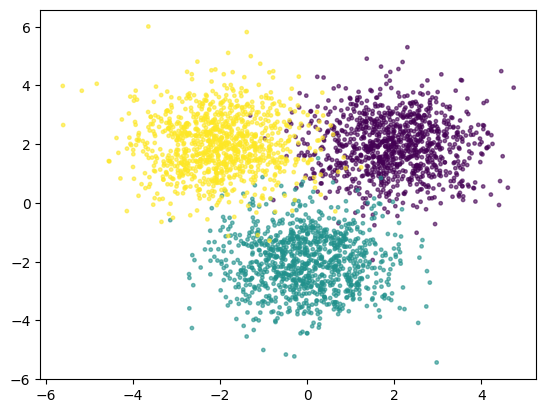

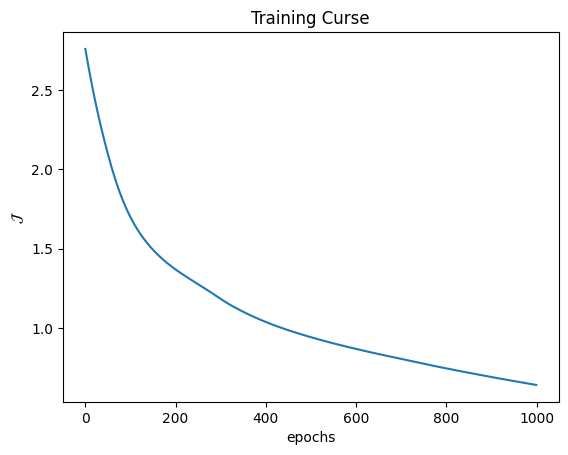

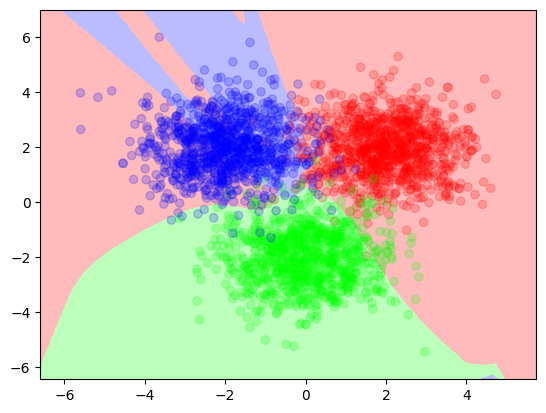

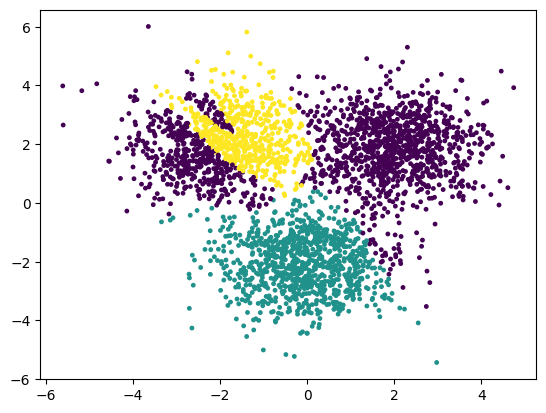

In [20]:
if __name__ == '__main__':
    main()

In [ ]:
0.16671271